=== Part 1.2 — DecisionTreeRegressor (default) ===
MAE : 0.455
RMSE: 0.704
R2  : 0.622

=== Q2 — Metrics DataFrame ===


,MAE,RMSE,R2
0,0.455,0.704,0.622



=== Part 2.2 — Cross-validation results ===
Scores (negative RMSE): [-0.73676068 -0.72366202 -0.72052253 -0.72771551 -0.70514645]
Mean RMSE: 0.7227614362911459
Std dev : 0.010359854323167076

=== Q4 — RMSE comparison ===
RMSE test (single split): 0.7242338143386247
RMSE CV mean (5 folds)  : 0.7227614362911459
Difference (test - CV)  : 0.001472378047478795

=== Part 2.3 — Model comparison (CV) ===


,model,rmse_cv_mean,rmse_cv_std
0,RandomForest,0.511062,0.011490
1,GradientBoosting,0.532113,0.011559
2,DecisionTree,0.733320,0.023568



=== Part 2.3 — Best model retrain + test ===
Best model (by CV): RandomForest
Best model test RMSE: 0.5053399773665033
Best model CV RMSE  : 0.5110617196213492

=== Part 3.1 — Depth sweep results ===


,max_depth,rmse_cv
0,2,0.859221
1,3,0.795664
2,4,0.755470
3,5,0.712606
4,6,0.676735
5,7,0.652650
6,8,0.636682
7,9,0.632814
8,10,0.642836


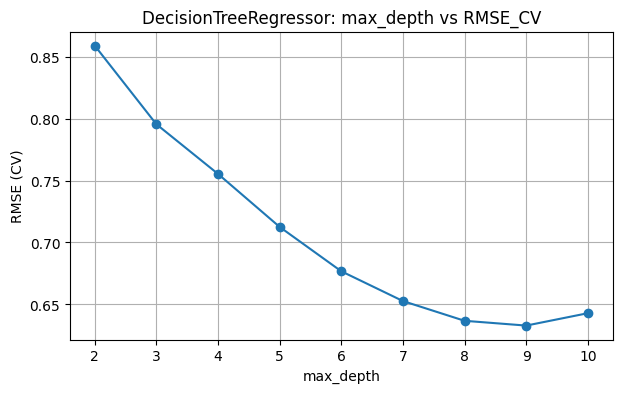

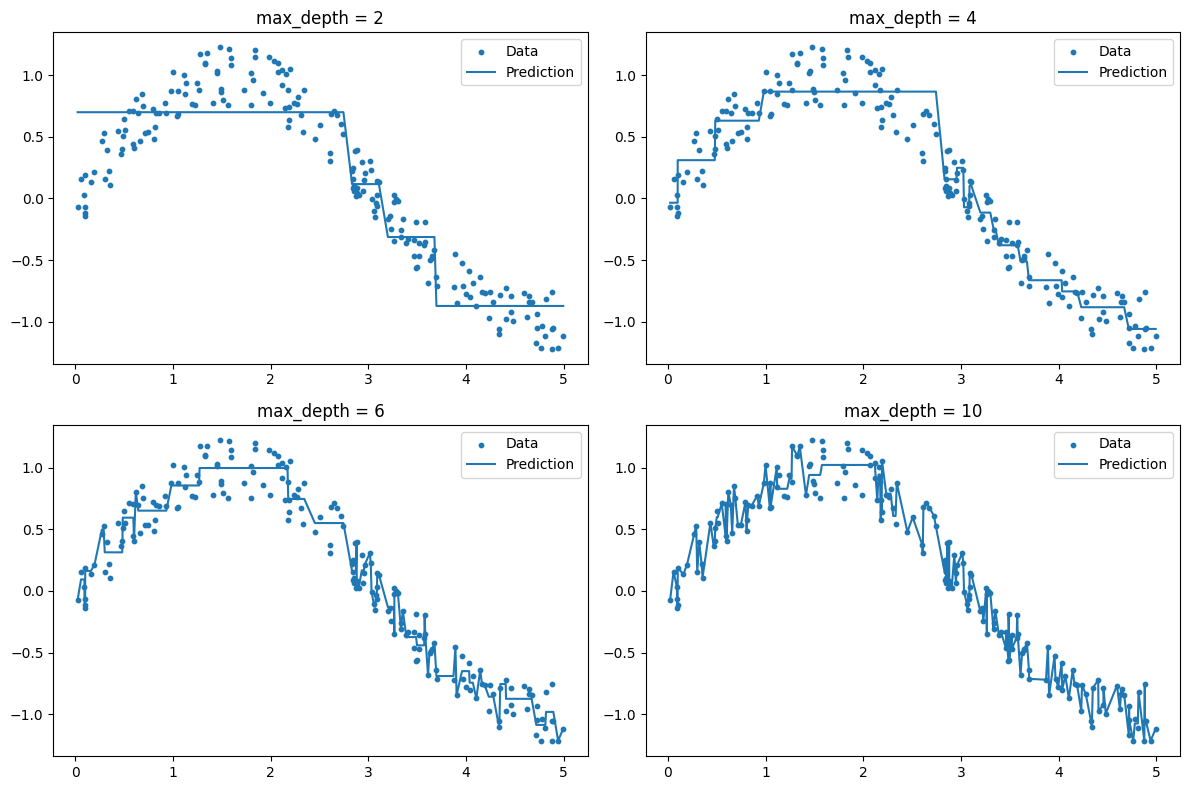

In [10]:
# ============================================================
# TP5 — Regression, Cross-Validation, and Model Complexity Control
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.max_columns", None)

# ============================================================
# Part 1 — Classification vs Regression
# ============================================================

# Q1 (Write your answer in a Markdown cell)
# - Classification predicts a discrete label (spam/not spam, benign/malignant).
# - Regression predicts a continuous value (house price, temperature, duration).
# Example:
#   - "Will a machine fail in the next 24h?" -> classification
#   - "How many hours remaining before failure?" -> regression

# -----------------------------
# Part 1.2 — California Housing
# -----------------------------

# Load dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train baseline regressor
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train, y_train)

# Predict + evaluate
preds = reg.predict(X_test)

mae = mean_absolute_error(y_test, preds)

# NOTE: your sklearn does NOT support squared=False, so compute RMSE manually
rmse = np.sqrt(mean_squared_error(y_test, preds))

r2 = r2_score(y_test, preds)

print("=== Part 1.2 — DecisionTreeRegressor (default) ===")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

# -----------------------------
# Q2 — Metrics as a DataFrame
# -----------------------------
metrics_df = pd.DataFrame([{"MAE": mae, "RMSE": rmse, "R2": r2}]).round(3)
print("\n=== Q2 — Metrics DataFrame ===")
display(metrics_df)

# Q2 (Write short comment in Markdown cell):
# - MAE: average absolute error (lower is better)
# - RMSE: penalizes large errors more (lower is better)
# - R²: variance explained (1 best, 0 baseline, negative worse than baseline)

# ============================================================
# Part 2 — Cross-validation
# ============================================================

# --------------------------------
# Part 2.2 — K-Fold Cross-Validation
# --------------------------------

reg_cv = DecisionTreeRegressor(max_depth=5, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    reg_cv,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

print("\n=== Part 2.2 — Cross-validation results ===")
print("Scores (negative RMSE):", scores)
print("Mean RMSE:", -scores.mean())
print("Std dev :", scores.std())

# Q3 (Write your answer in Markdown cell):
# sklearn maximizes scores. RMSE is a loss (lower is better),
# so sklearn returns -RMSE. To interpret RMSE, take the negative:
# RMSE = -score, mean RMSE = -scores.mean().

# -----------------------------
# Q4 — Compare CV RMSE vs Test RMSE
# -----------------------------
reg_test = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_test.fit(X_train, y_train)

preds_test = reg_test.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

rmse_cv_mean = -scores.mean()

print("\n=== Q4 — RMSE comparison ===")
print("RMSE test (single split):", rmse_test)
print("RMSE CV mean (5 folds)  :", rmse_cv_mean)
print("Difference (test - CV)  :", rmse_test - rmse_cv_mean)

# Q4 (Write short comment in Markdown cell):
# CV RMSE is usually more reliable because it averages multiple splits.
# Test RMSE depends on one split, so it may be slightly better or worse than CV mean.

# --------------------------------
# Part 2.3 — Model selection via cross-validation
# --------------------------------

def evaluate_model(model, X, y, k=5):
    """Return (mean_rmse, std_rmse) using k-fold CV."""
    kf_local = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X, y,
        scoring="neg_root_mean_squared_error",
        cv=kf_local
    )
    return -scores.mean(), scores.std()

models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

rows = []
for name, model in models.items():
    mean_rmse, std_rmse = evaluate_model(model, X_train, y_train, k=5)
    rows.append({"model": name, "rmse_cv_mean": mean_rmse, "rmse_cv_std": std_rmse})

compare_df = pd.DataFrame(rows).sort_values("rmse_cv_mean").reset_index(drop=True)

print("\n=== Part 2.3 — Model comparison (CV) ===")
display(compare_df)

# Train the best model on full training set and evaluate on test set
best_name = compare_df.loc[0, "model"]
best_model = models[best_name]

best_model.fit(X_train, y_train)
preds_best = best_model.predict(X_test)
rmse_best_test = np.sqrt(mean_squared_error(y_test, preds_best))

print("\n=== Part 2.3 — Best model retrain + test ===")
print("Best model (by CV):", best_name)
print("Best model test RMSE:", rmse_best_test)
print("Best model CV RMSE  :", compare_df.loc[0, "rmse_cv_mean"])

# ============================================================
# Part 3 — max_depth (complexity control)
# ============================================================

# --------------------------------
# Part 3.1 — Sweep max_depth from 2 to 10 (CV RMSE)
# --------------------------------

depth_results = []
for depth in range(2, 11):
    reg_depth = DecisionTreeRegressor(max_depth=depth, random_state=42)
    rmse_cv = -cross_val_score(
        reg_depth,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    ).mean()
    depth_results.append({"max_depth": depth, "rmse_cv": rmse_cv})

results_df = pd.DataFrame(depth_results)

print("\n=== Part 3.1 — Depth sweep results ===")
display(results_df)

# Q5 — Plot max_depth vs rmse_cv
plt.figure(figsize=(7, 4))
plt.plot(results_df["max_depth"], results_df["rmse_cv"], marker="o")
plt.xlabel("max_depth")
plt.ylabel("RMSE (CV)")
plt.title("DecisionTreeRegressor: max_depth vs RMSE_CV")
plt.grid(True)
plt.show()

# Q5 (Write answer in Markdown cell):
# The RMSE usually decreases then stabilizes (or increases).
# The stabilization depth is where improvements become very small (plateau).

# --------------------------------
# Part 3.2 — Synthetic dataset: y = sin(x) + noise
# --------------------------------

rng = np.random.RandomState(0)
X_syn = np.sort(5 * rng.rand(200, 1), axis=0)
y_syn = np.sin(X_syn).ravel()
y_syn += 0.5 * (rng.rand(200) - 0.5)

depths = [2, 4, 6, 10]

plt.figure(figsize=(12, 8))
for i, depth in enumerate(depths, 1):
    reg_syn = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg_syn.fit(X_syn, y_syn)

    plt.subplot(2, 2, i)
    plt.scatter(X_syn, y_syn, s=10, label="Data")
    plt.plot(X_syn, reg_syn.predict(X_syn), label="Prediction")
    plt.title(f"max_depth = {depth}")
    plt.legend()

plt.tight_layout()
plt.show()

# Q6 (Write answer in Markdown cell):
# - Small depth (2): underfitting (high bias), too simple.
# - Medium depth (4–6): better tradeoff.
# - Large depth (10): overfitting (high variance), follows noise.

# ============================================================
# Part 4 — Short synthesis (write in Markdown cell)
# ============================================================

# 1) Regression vs classification: outputs + metrics + overfitting risk
# 2) How cross-validation helps choose features/hyperparameters
# 3) Strategy to choose max_depth: sweep 2–10, pick plateau/minimum, confirm on test
